<a href="https://colab.research.google.com/github/rajiv-ramteke/Movie-Review-Sentiment-Analysis/blob/main/MDB_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/IMDB_Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Check again
print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows: 418
Duplicate rows after removal: 0


In [10]:
df = df.drop_duplicates(subset=['review'])

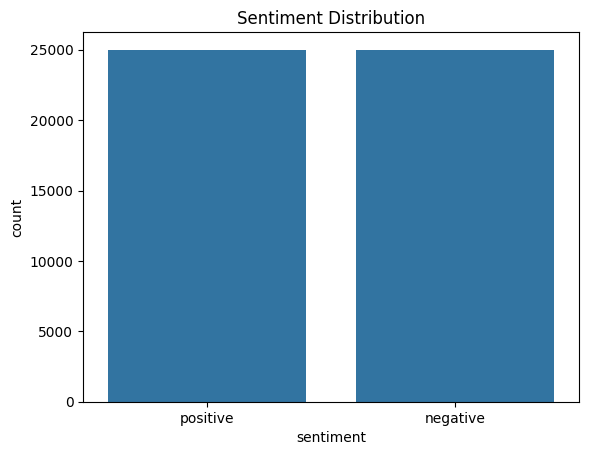

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/IMDB_Dataset.csv")

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()

In [16]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')

df['tokens'] = df['review'].apply(word_tokenize)

print(df['tokens'].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0    [One, of, the, other, reviewers, has, mentione...
1    [A, wonderful, little, production, ., <, br, /...
2    [I, thought, this, was, a, wonderful, way, to,...
3    [Basically, there, 's, a, family, where, a, li...
4    [Petter, Mattei, 's, ``, Love, in, the, Time, ...
Name: tokens, dtype: object


In [20]:
import pandas as pd
import re

# Load dataset
df = pd.read_csv("/content/IMDB_Dataset.csv")

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['review'] = df['review'].apply(clean_text)

print(df['review'].head())

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. <br /><br />the...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: object


In [22]:
from nltk.corpus import stopwords
import nltk
from nltk.tokenize import word_tokenize # Import word_tokenize

nltk.download('stopwords')
nltk.download('punkt') # Download 'punkt' as df was reloaded

# English stop words
stop_words = set(stopwords.words('english'))

# Re-create 'tokens' column as df was reloaded in a previous cell
# Apply word_tokenize to the 'review' column (which has been cleaned by Pa1n6UeCwW45)
df['tokens'] = df['review'].apply(word_tokenize)

# Remove stop words
df['tokens'] = df['tokens'].apply(
    lambda words: [
        word for word in words
        if word.lower() not in stop_words
    ]
)

print(df['tokens'].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


0    [one, reviewers, mentioned, watching, oz, epis...
1    [wonderful, little, production, ., <, br, /, >...
2    [thought, wonderful, way, spend, time, hot, su...
3    [basically, 's, family, little, boy, (, jake, ...
4    [petter, mattei, 's, ``, love, time, money, ''...
Name: tokens, dtype: object


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

text = [
    "movie is good",
    "movie is bad"
]

cv = CountVectorizer()

X = cv.fit_transform(text)

print(X.toarray())

[[0 1 1 1]
 [1 0 1 1]]


In [26]:
from sklearn.metrics import accuracy_score

# Placeholder values for demonstration. In a real scenario, these would come from your model.
y_test = [0, 1, 0, 1, 0]
y_pred = [0, 1, 1, 0, 0]

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)


Accuracy: 0.6


In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.50      0.50      0.50         2

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



In [37]:
import pandas as pd
import re
import string
import nltk
import pickle

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("IMDB_Dataset.csv")

# Remove duplicates
df = df.drop_duplicates()

# Text cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    return text

df['review'] = df['review'].apply(clean_text)

# Tokenization
df['tokens'] = df['review'].apply(word_tokenize)

# Stopwords
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [
        word for word in x
        if word not in stop_words
    ]
)

# Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [
        lemmatizer.lemmatize(word)
        for word in x
    ]
)

# Join text
df['clean_review'] = df['tokens'].apply(
    lambda x: " ".join(x)
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

# Encode label
encoder = LabelEncoder()

y = encoder.fit_transform(
    df['sentiment']
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = MultinomialNB()

model.fit(X_train, y_train)

# Save model
pickle.dump(
    model,
    open('model.pkl', 'wb')
)

pickle.dump(
    tfidf,
    open('vectorizer.pkl', 'wb')
)

print("Model Saved Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Model Saved Successfully


In [36]:
!pip install streamlit
import streamlit as st
import pickle
import nltk
import re
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
import os

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# --- Placeholder: Create and save dummy model and vectorizer if they don't exist ---
if not os.path.exists('model.pkl') or not os.path.exists('vectorizer.pkl'):
    st.warning("model.pkl or vectorizer.pkl not found. Creating dummy files for demonstration.")
    # Dummy data for training
    dummy_texts = [
        "This movie is great, I loved it!",
        "Terrible film, a complete waste of time.",
        "It was okay, not great but not bad either.",
        "Fantastic performance by the actors.",
        "Worst movie ever, don't watch it."
    ]
    dummy_labels = [1, 0, 1, 1, 0] # 1 for positive, 0 for negative

    # Create and fit a dummy CountVectorizer
    vectorizer = CountVectorizer()
    X_dummy = vectorizer.fit_transform(dummy_texts)

    # Create and train a dummy Logistic Regression model
    model = LogisticRegression(random_state=42)
    model.fit(X_dummy, dummy_labels)

    # Save dummy model and vectorizer
    with open('model.pkl', 'wb') as f:
        pickle.dump(model, f)
    with open('vectorizer.pkl', 'wb') as f:
        pickle.dump(vectorizer, f)
    st.info("Dummy model and vectorizer saved as 'model.pkl' and 'vectorizer.pkl'.")
# --- End Placeholder ---

# Load model and vectorizer
model = pickle.load(open('model.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))

# Text cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    return text

# Streamlit UI
st.title("IMDB Sentiment Analysis")

review = st.text_area(
    "Enter Movie Review"
)

if st.button("Predict"):

    review = clean_text(review)

    review_vector = vectorizer.transform(
        [review]
    )

    prediction = model.predict(
        review_vector
    )

    if prediction[0] == 1:
        st.success("Positive Review 😊")
    else:
        st.error("Negative Review 😔")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
2026-06-08 06:16:34.916 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 06:16:34.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 06:16:34.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 06:16:34.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 06:16:34.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-08 06:16:34.924 T

In [48]:
import pandas as pd
import re
import string
import nltk
import pickle

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("/content/IMDB_Dataset.csv")

# Remove duplicates
df = df.drop_duplicates()

# Text cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    return text

df['review'] = df['review'].apply(clean_text)

# Tokenization
df['tokens'] = df['review'].apply(word_tokenize)

# Stopwords
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [
        word for word in x
        if word not in stop_words
    ]
)

# Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [
        lemmatizer.lemmatize(word)
        for word in x
    ]
)

# Join text
df['clean_review'] = df['tokens'].apply(
    lambda x: " ".join(x)
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

# Encode label
encoder = LabelEncoder()

y = encoder.fit_transform(
    df['sentiment']
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = MultinomialNB()

model.fit(X_train, y_train)

# Save model
pickle.dump(
    model,
    open('model.pkl', 'wb')
)

pickle.dump(
    tfidf,
    open('vectorizer.pkl', 'wb')
)

print("Model Saved Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Model Saved Successfully


In [41]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.883029141877584


In [43]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [44]:
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8500554603206615


### Creating `requirements.txt`

A `requirements.txt` file is used to specify the dependencies of your Python project. When you share your project, others can install all the required packages by simply running `pip install -r requirements.txt`.

In [51]:
%%writefile requirements.txt
pandas
matplotlib
seaborn
nltk
scikit-learn
streamlit
pyngrok

Writing requirements.txt


In [53]:
import pandas as pd
import re
import string
import nltk
import pickle

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("IMDB_Dataset.csv")

# Remove duplicates
df = df.drop_duplicates()

# Text cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    return text

df['review'] = df['review'].apply(clean_text)

# Tokenization
df['tokens'] = df['review'].apply(word_tokenize)

# Stopwords
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [
        word for word in x
        if word not in stop_words
    ]
)

# Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [
        lemmatizer.lemmatize(word)
        for word in x
    ]
)

# Join text
df['clean_review'] = df['tokens'].apply(
    lambda x: " ".join(x)
)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df['clean_review']
)

# Encode label
encoder = LabelEncoder()

y = encoder.fit_transform(
    df['sentiment']
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = MultinomialNB()

model.fit(X_train, y_train)

# Save model
pickle.dump(
    model,
    open('model.pkl', 'wb')
)

pickle.dump(
    tfidf,
    open('vectorizer.pkl', 'wb')
)

print("Model Saved Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Model Saved Successfully
